# 1/4 drone MPC

This script runs an optimal MPC (using casadi) for the 1/4 drone case study, using a NARX model identified.

In [1]:
# 1. Imports and Definitions
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm.auto import tqdm
from casadi import SX, MX, DM, Function, nlpsol, vertcat
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

Ts = 0.05  # Sampling time in seconds
ny_model = 5
nu_model = 5
nx = ny_model + nu_model


C:\Users\mathe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 2. CasADi Formulation of Hard-coded NARX Model
x = SX.sym('x', nx)
y_syms = [x[i] for i in range(ny_model)]
u_syms = [x[ny_model + i] for i in range(nu_model)]
u_sym = SX.sym('u')

# Hard-coded NARX equation identified via FROLS
y_k = (
    + 1.9373 * (y_syms[0])
    - 0.9545 * (y_syms[1])
    + 0.0007 * (u_syms[1] * u_syms[1])
    + 0.0000 * (u_syms[3] * u_syms[4] * u_syms[4])
    - 0.0004 * (u_syms[1] * u_syms[2])
)

y_next = vertcat(y_k, x[0:ny_model-1])
u_next = vertcat(u_sym, x[ny_model:ny_model+nu_model-1])
x_next = vertcat(y_next, u_next)

F = Function('F', [x, u_sym], [x_next, y_k], ['x0', 'p'], ['xf', 'yk'])


In [3]:
# 3. MPC Setup
N = 10
data = {
    'Ts': Ts,
    'x0': np.zeros(nx),
    'u_min': np.array([0.0]),
    'u_max': np.array([100.0]),
    'u_guess': np.array([0.0]),
    'x_guess': np.zeros(nx),
    'tol': 1e-8,
}

def vcat(lst):
    return vertcat(*[DM(x) if not hasattr(x, 'is_symbolic') else x for x in lst])

w, lbw, ubw, w0 = [], [], [], []
g, lbg, ubg = [], [], []
J = 0

xk_param = MX.sym('xk_param', nx)
Pref = MX.sym('Pref', N)

xk = MX.sym('x0', nx)
w.append(xk)
lbw.append(np.full(nx, -np.inf))
ubw.append(np.full(nx, np.inf))
w0.append(data['x_guess'])

g.append(xk - xk_param)
lbg.append(np.zeros(nx))
ubg.append(np.zeros(nx))

for k in range(N):
    uk = MX.sym(f'u_{k}', 1)
    w.append(uk)
    lbw.append(data['u_min'])
    ubw.append(data['u_max'])
    w0.append(data['u_guess'])
    
    Fk = F(x0=xk, p=uk)
    xnext = Fk['xf']
    yk = Fk['yk']
    
    if k == 0:
        du = uk - xk[ny_model]
    else:
        du = uk - u_prev
    u_prev = uk
    
    J = J + 1e3 * (yk - Pref[k])**2 + 0.1 * uk**2 + 50.0 * du**2
    
    xk = MX.sym(f'x_{k+1}', nx)
    w.append(xk)
    lbw.append(np.full(nx, -np.inf))
    ubw.append(np.full(nx, np.inf))
    w0.append(data['x_guess'])
    
    g.append(xk - xnext)
    lbg.append(np.zeros(nx))
    ubg.append(np.zeros(nx))

w = vertcat(*w)
lbw = vcat(lbw)
ubw = vcat(ubw)
w0 = vcat(w0)
g = vertcat(*g)
lbg = vcat(lbg)
ubg = vcat(ubg)

nlp = {'x': w, 'g': g, 'f': J, 'p': vertcat(xk_param, Pref)}
solver = nlpsol('solver', 'ipopt', nlp, {'ipopt.print_level': 0, 'print_time': 0})


In [4]:
# 4. Reference Sequence Generation
# Sequence of 5s each, from 0 to 90 with step of 10
step_duration = 5.0
samples_per_step = int(round(step_duration / Ts))
step_levels = np.arange(0, 100, 10)  # 0, 10, ..., 90

t_total = len(step_levels) * step_duration
steps = len(step_levels) * samples_per_step

tvec = np.arange(0, t_total, Ts)
x2ref = np.zeros(steps)

for i, level in enumerate(step_levels):
    x2ref[i*samples_per_step : (i+1)*samples_per_step] = level

# Padding for MPC horizon
x2ref_full = np.concatenate([x2ref, np.full(N, 90.0)])


In [5]:
# 5. Simulation Loop
xsim = np.zeros((nx, 1))
ysim = []
usim = []
tvec_sim = []
dtvec = []

w0_val = np.zeros(w.shape[0])

for k in tqdm(range(steps), desc="MPC Simulation"):
    t = k * Ts
    ref_window = x2ref_full[k : k + N]
    
    pval = np.concatenate([xsim[:, -1], ref_window])
    
    tic = time.perf_counter()
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    dtvec.append(time.perf_counter() - tic)
    
    w_opt = sol['x'].full().flatten()
    u_opt = w_opt[nx] # The first u after the initial x0
    
    # Open Loop Simulation using NARX model F
    sim_step = F(x0=xsim[:, -1], p=u_opt)
    xk1 = sim_step['xf'].full().flatten()
    yk = sim_step['yk'].full().item()
    
    xsim = np.c_[xsim, xk1]
    usim.append(u_opt)
    ysim.append(yk)
    tvec_sim.append(t)
    
    # Warm start
    w0_val = w_opt


MPC Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

MPC Simulation:   0%|          | 5/1000 [00:00<00:21, 47.11it/s]


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



MPC Simulation:   1%|          | 11/1000 [00:00<00:19, 49.68it/s]

MPC Simulation:   2%|▏         | 16/1000 [00:00<00:20, 48.82it/s]

...

MPC Simulation:  95%|█████████▌| 954/1000 [00:09<00:00, 126.50it/s]

MPC Simulation:  97%|█████████▋| 968/1000 [00:09<00:00, 128.94it/s]

MPC Simulation:  98%|█████████▊| 983/1000 [00:09<00:00, 134.61it/s]

MPC Simulation: 100%|█████████▉| 998/1000 [00:09<00:00, 136.62it/s]

MPC Simulation: 100%|██████████| 1000/1000 [00:09<00:00, 101.76it/s]

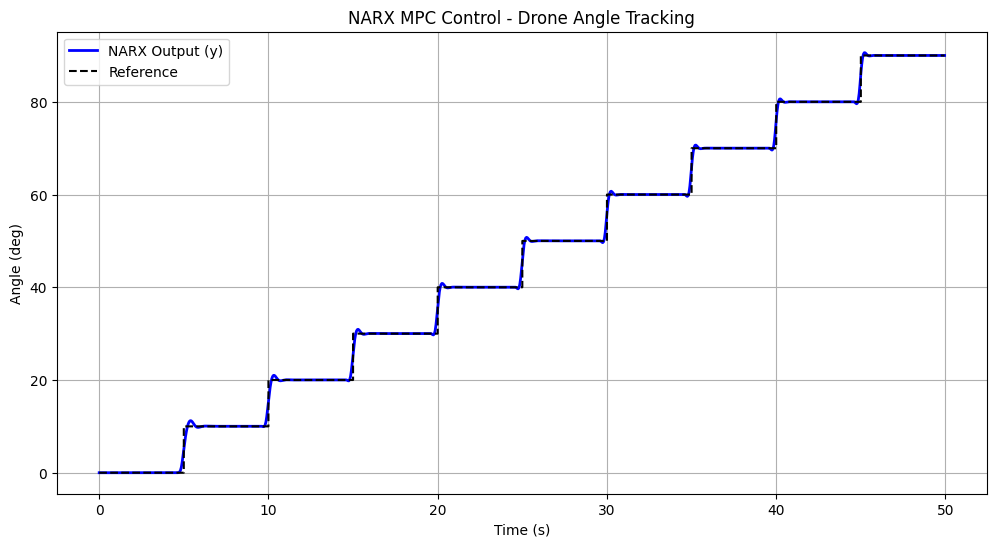

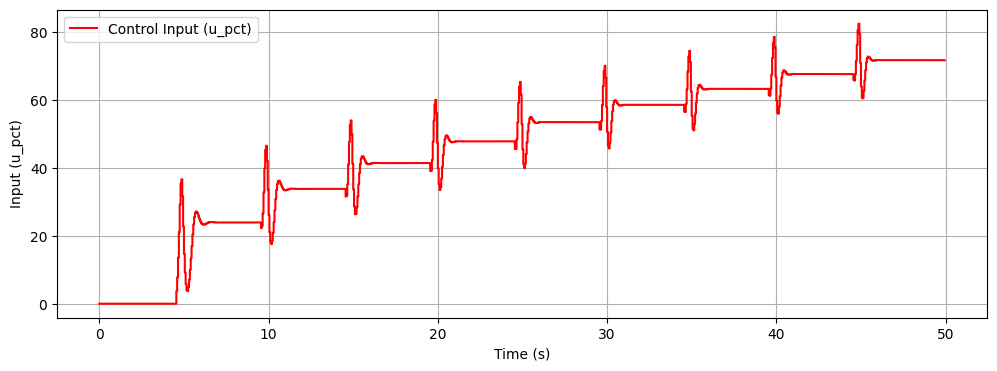

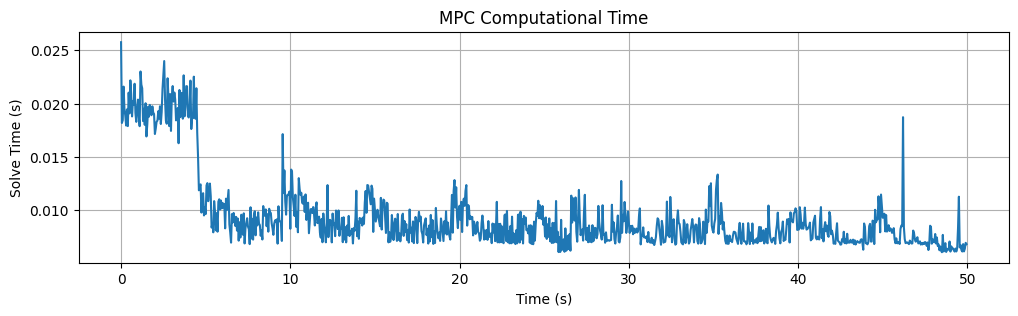

In [6]:
# 6. Plotting Results
plt.figure(figsize=(12, 6))
plt.plot(tvec_sim, ysim, 'b-', linewidth=2, label='NARX Output (y)')
plt.step(tvec_sim, x2ref[:len(tvec_sim)], where='post', color='k', linestyle='--', label='Reference')
plt.ylabel('Angle (deg)')
plt.xlabel('Time (s)')
plt.title('NARX MPC Control - Drone Angle Tracking')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.step(tvec_sim, usim, where='post', color='r', label='Control Input (u_pct)')
plt.ylabel('Input (u_pct)')
plt.xlabel('Time (s)')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(tvec_sim, dtvec)
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('Solve Time (s)')
plt.title('MPC Computational Time')
plt.show()


## Dataset Generation
Using a rich combination of sine, step, and chirp signals.

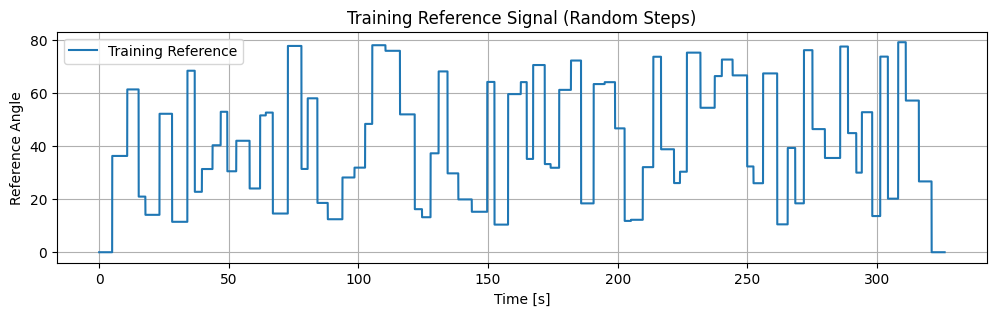

In [7]:
# 7. Training Reference Signal Generation (Random Steps)
np.random.seed(42)

# --- ADJUSTABLE PARAMETERS ---
n_steps = 80          # Number of random steps (NEW: increased for larger dataset)
step_duration_min = 2.0  # Minimum step duration in seconds (NEW)
step_duration_max = 6.0  # Maximum step duration in seconds (NEW: covers validation step length)
amp_min = 10.0        # Minimum amplitude for the steps
amp_max = 80.0        # Maximum amplitude for the steps
zero_duration = 5.0   # Duration of zero-signal padding at start and end [s]
# -----------------------------

train_pieces = []
for i in range(n_steps):
    # Generate a random amplitude and duration for this step
    S = np.random.uniform(amp_min, amp_max)
    dur = np.random.uniform(step_duration_min, step_duration_max)  # NEW: random step duration
    samples_step = int(round(dur / Ts))  # NEW: using random duration
    train_pieces.append(np.full(samples_step, S))

# Initial and final zero padding
n_zero_samples = int(round(zero_duration / Ts)) + 1 
zerovec = np.zeros(n_zero_samples)
x2ref_train = np.concatenate([zerovec, np.concatenate(train_pieces), zerovec])

steps_train = len(x2ref_train)
tvec_train = np.arange(0, steps_train * Ts, Ts)

# Plotting the generated steps
plt.figure(figsize=(12, 3))
plt.plot(tvec_train, x2ref_train, label='Training Reference')
plt.xlabel('Time [s]')
plt.ylabel('Reference Angle')
plt.title('Training Reference Signal (Random Steps)')
plt.legend()
plt.grid(True)
plt.show()


Simulating MPC over Rich Signal for Dataset...


MPC Dataset Collection:   0%|          | 0/6513 [00:00<?, ?it/s]

MPC Dataset Collection:   0%|          | 8/6513 [00:00<01:27, 74.42it/s]

MPC Dataset Collection:   0%|          | 16/6513 [00:00<01:41, 64.31it/s]

MPC Dataset Collection:   0%|          | 23/6513 [00:00<01:39, 65.08it/s]

...

MPC Dataset Collection:  99%|█████████▉| 6480/6513 [01:03<00:00, 82.66it/s]

MPC Dataset Collection: 100%|█████████▉| 6489/6513 [01:04<00:00, 76.16it/s]

MPC Dataset Collection: 100%|█████████▉| 6499/6513 [01:04<00:00, 81.20it/s]

MPC Dataset Collection: 100%|█████████▉| 6508/6513 [01:04<00:00, 77.43it/s]

MPC Dataset Collection: 100%|██████████| 6513/6513 [01:04<00:00, 101.24it/s]

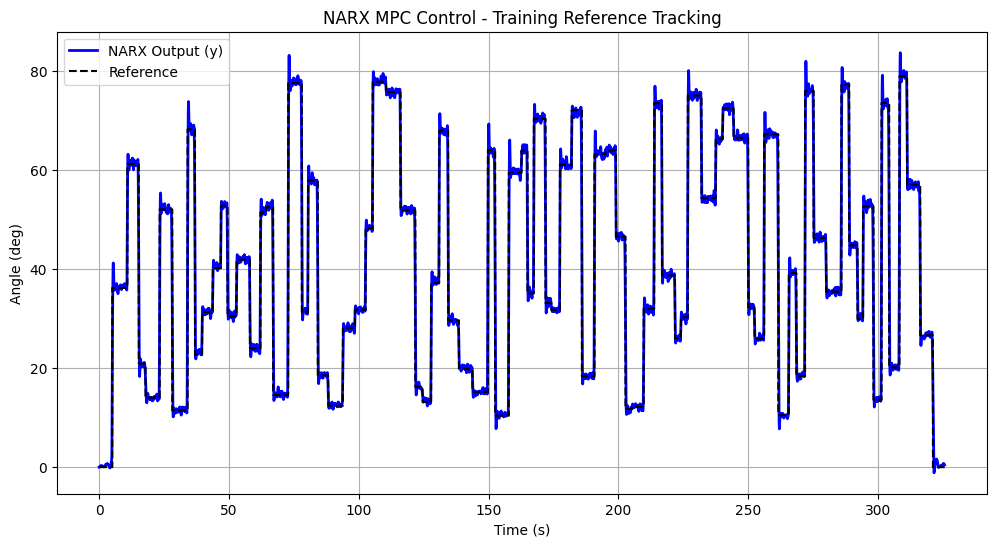

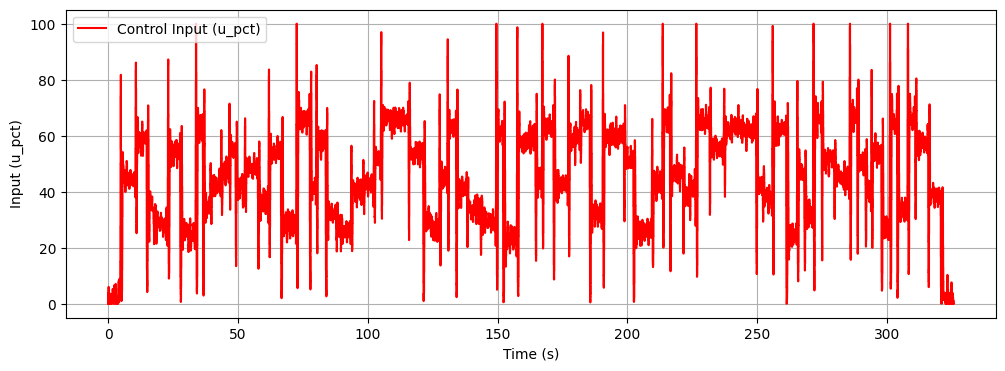

In [8]:
# 8. Simulation Loop (Rich Signal Dataset Collection)
xsim_train = np.zeros((nx, 1))
ysim_train = []
usim_train = []
w0_val = np.zeros(w.shape[0])

print("Simulating MPC over Rich Signal for Dataset...")
sim_steps_train = steps_train - N
for k in tqdm(range(sim_steps_train), desc="MPC Dataset Collection"):
    ref_window = x2ref_train[k : k + N]
    pval = np.concatenate([xsim_train[:, -1], ref_window])
    
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    
    w_opt = sol['x'].full().flatten()
    u_opt = w_opt[nx]
    
    # Add exploratory noise to the applied control input (NEW)
    u_applied = np.random.normal(u_opt, 3.0)  # NEW: standard deviation of 3.0% control noise
    u_applied = np.clip(u_applied, data['u_min'][0], data['u_max'][0])  # NEW: respect bounds
    
    sim_step = F(x0=xsim_train[:, -1], p=u_applied)  # NEW: apply noisy control to model
    xk1 = sim_step['xf'].full().flatten()
    yk = sim_step['yk'].full().item()
    
    xsim_train = np.c_[xsim_train, xk1]
    usim_train.append(u_opt)  # Target remains the optimal control (NEW)
    ysim_train.append(yk)
    w0_val = w_opt

# Collect Dataset for ANN
# P_data = np.array([np.concatenate([xsim_train[:, k], x2ref_train[k : k + N]]) for k in range(sim_steps_train)])
P_data = np.array([np.concatenate([xsim_train[:, k], x2ref_train[k : k + N]]) for k in range(sim_steps_train)])
U_data = np.array(usim_train).reshape(-1, 1)


# --- Plotting MPC Results ---
tvec_sim_train = tvec_train[:sim_steps_train]
# 1. Output (y) vs Reference
plt.figure(figsize=(12, 6))
plt.plot(tvec_sim_train, ysim_train, 'b-', linewidth=2, label='NARX Output (y)')
plt.step(tvec_sim_train, x2ref_train[:sim_steps_train], where='post', color='k', linestyle='--', label='Reference')
plt.ylabel('Angle (deg)')
plt.xlabel('Time (s)')
plt.title('NARX MPC Control - Training Reference Tracking')
plt.grid(True)
plt.legend()
plt.show()
# 2. Control Input (u)
plt.figure(figsize=(12, 4))
plt.step(tvec_sim_train, usim_train, where='post', color='r', label='Control Input (u_pct)')
plt.ylabel('Input (u_pct)')
plt.xlabel('Time (s)')
plt.grid(True)
plt.legend()
plt.show()


Training ANN...


Epoch 10/150 - Train Loss: 6.2155 - Val Loss: 5.5234


Epoch 20/150 - Train Loss: 4.0516 - Val Loss: 3.3861


Epoch 30/150 - Train Loss: 2.8085 - Val Loss: 2.2803


Epoch 40/150 - Train Loss: 2.2575 - Val Loss: 2.4307


...

Epoch 110/150 - Train Loss: 0.4630 - Val Loss: 0.9212


Epoch 120/150 - Train Loss: 0.4673 - Val Loss: 0.5848


Epoch 130/150 - Train Loss: 0.3827 - Val Loss: 0.4112


Epoch 140/150 - Train Loss: 0.3462 - Val Loss: 0.3599


Epoch 150/150 - Train Loss: 0.2999 - Val Loss: 0.3861


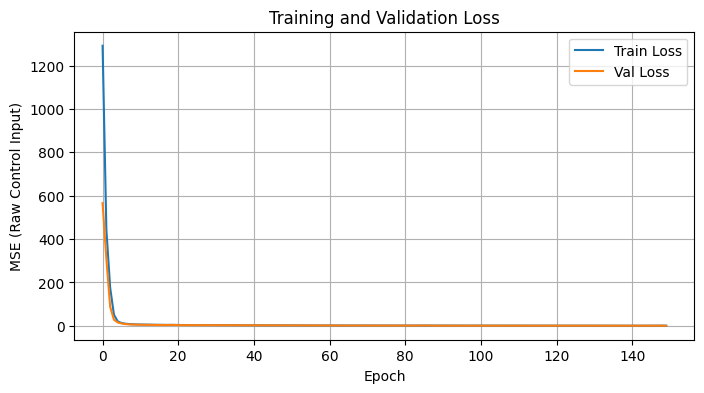

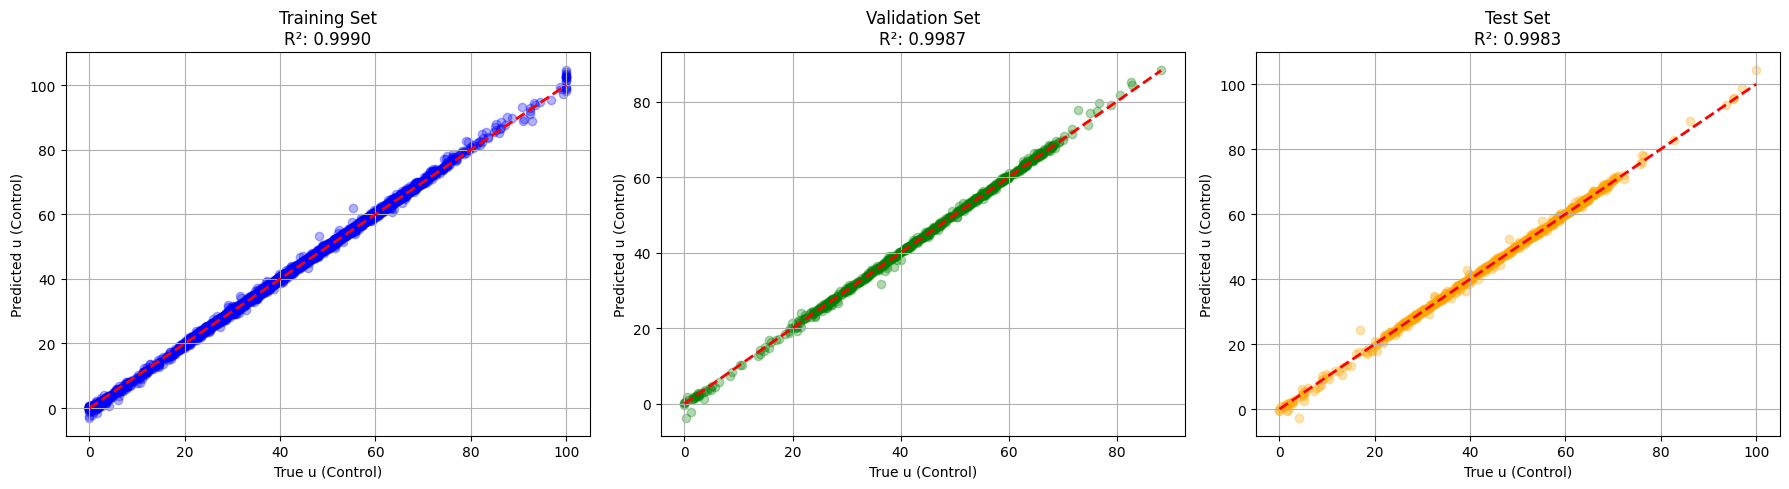

In [9]:
# 9. ANN Creation and Training
# Define the MLP (increased capacity for nx+N=35 inputs)
class MPCApproximator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MPCApproximator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

# Normalize inputs ONLY using StandardScaler to match robust template
scaler = StandardScaler()
P_scaled = scaler.fit_transform(P_data)

# Split data into train, validation, and test sets to monitor overfitting and evaluate generalization
X_train_val, X_test, y_train_val, y_test = train_test_split(P_scaled, U_data, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1111, random_state=42)

tensor_X_train = torch.tensor(X_train, dtype=torch.float32)
tensor_y_train = torch.tensor(y_train, dtype=torch.float32)
tensor_X_val = torch.tensor(X_val, dtype=torch.float32)
tensor_y_val = torch.tensor(y_val, dtype=torch.float32)
tensor_X_test = torch.tensor(X_test, dtype=torch.float32)
tensor_y_test = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(tensor_X_train, tensor_y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# model = MPCApproximator(input_dim=nx + N, output_dim=1)
model = MPCApproximator(input_dim=nx + N, output_dim=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # NEW: reduced for training stability

epochs = 150  # NEW: increased epochs to allow model to converge fully
train_loss_history = []
val_loss_history = []

print("Training ANN...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_loss_history.append(epoch_loss / len(train_loader))
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(tensor_X_val)
        val_loss = criterion(val_outputs, tensor_y_val).item()
    val_loss_history.append(val_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss_history[-1]:.4f} - Val Loss: {val_loss_history[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE (Raw Control Input)")
plt.legend()
plt.grid()
plt.show()

# Plot y vs yhat on training, val, and test (side by side)
model.eval()
with torch.no_grad():
    y_train_pred = model(tensor_X_train).numpy()
    y_val_pred = model(tensor_X_val).numpy()
    y_test_pred = model(tensor_X_test).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training plot
axes[0].scatter(y_train, y_train_pred, alpha=0.3, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_title(f"Training Set\nR²: {r2_score(y_train, y_train_pred):.4f}")
axes[0].set_xlabel("True u (Control)")
axes[0].set_ylabel("Predicted u (Control)")
axes[0].grid(True)

# Validation plot
axes[1].scatter(y_val, y_val_pred, alpha=0.3, color='green')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_title(f"Validation Set\nR²: {r2_score(y_val, y_val_pred):.4f}")
axes[1].set_xlabel("True u (Control)")
axes[1].set_ylabel("Predicted u (Control)")
axes[1].grid(True)

# Test plot
axes[2].scatter(y_test, y_test_pred, alpha=0.3, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title(f"Test Set\nR²: {r2_score(y_test, y_test_pred):.4f}")
axes[2].set_xlabel("True u (Control)")
axes[2].set_ylabel("Predicted u (Control)")
axes[2].grid(True)

plt.tight_layout()
plt.show()


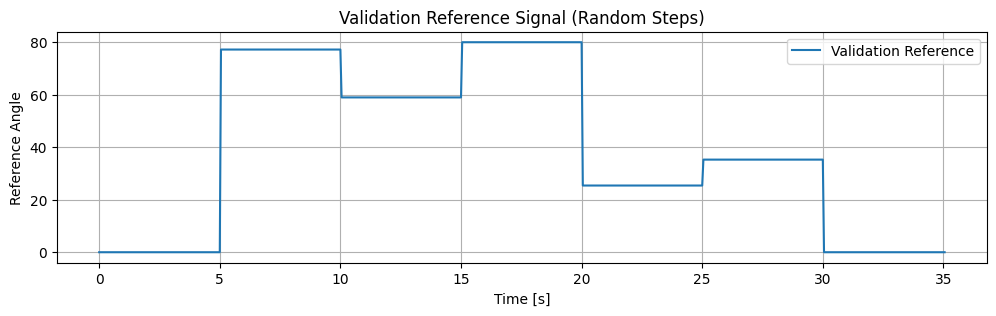

In [10]:
# 10. Validation Test Signal Generation
np.random.seed(24)  # Different seed than training to ensure a unique validation signal

# --- ADJUSTABLE PARAMETERS ---
n_steps_val = 5          # Number of validation random steps
step_duration_val = 5.0   # Duration of each step in seconds
amp_min_val = 10.0        # Minimum amplitude for the steps
amp_max_val = 80.0        # Maximum amplitude for the steps
zero_duration_val = 5.0   # Duration of zero-signal padding at start and end [s]
# -----------------------------

val_pieces = []
for i in range(n_steps_val):
    # Generate a random amplitude for this step
    S = np.random.uniform(amp_min_val, amp_max_val) 
    samples_step = int(round(step_duration_val / Ts))
    val_pieces.append(np.full(samples_step, S))

# Initial and final zero padding
n_zero_samples = int(round(zero_duration_val / Ts)) + 1 
zerovec = np.zeros(n_zero_samples)
x2ref_val = np.concatenate([zerovec, np.concatenate(val_pieces), zerovec])

steps_test = len(x2ref_val)
tvec_test = np.arange(0, steps_test * Ts, Ts)

plt.figure(figsize=(12, 3))
plt.plot(tvec_test, x2ref_val, label='Validation Reference')
plt.xlabel('Time [s]')
plt.ylabel('Reference Angle')
plt.title('Validation Reference Signal (Random Steps)')
plt.legend()
plt.grid(True)
plt.show()


Simulating Optimal MPC on Test Signal...


Simulating ANN on Test Signal...


MPC Simulation Time: 7.36 s
ANN Simulation Time: 0.36 s
Speedup Factor: 20.45x


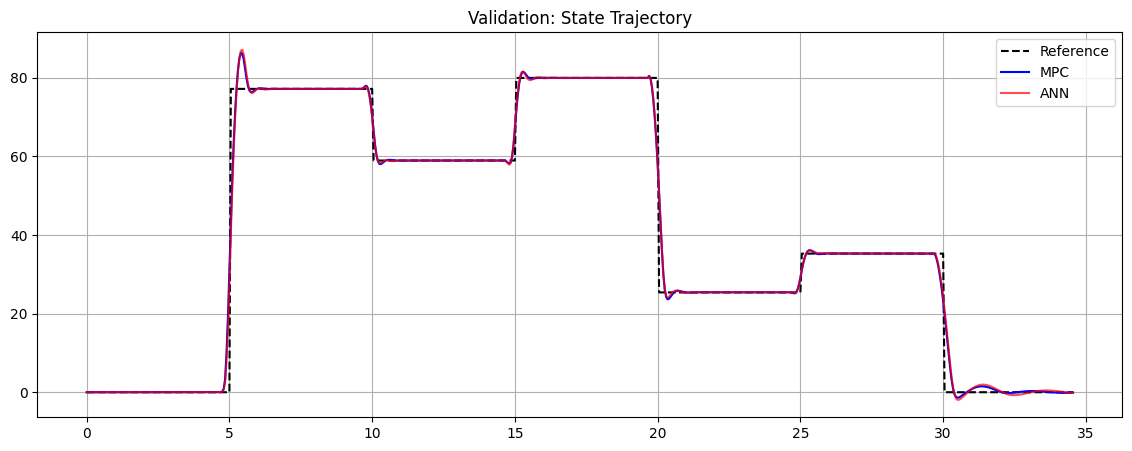

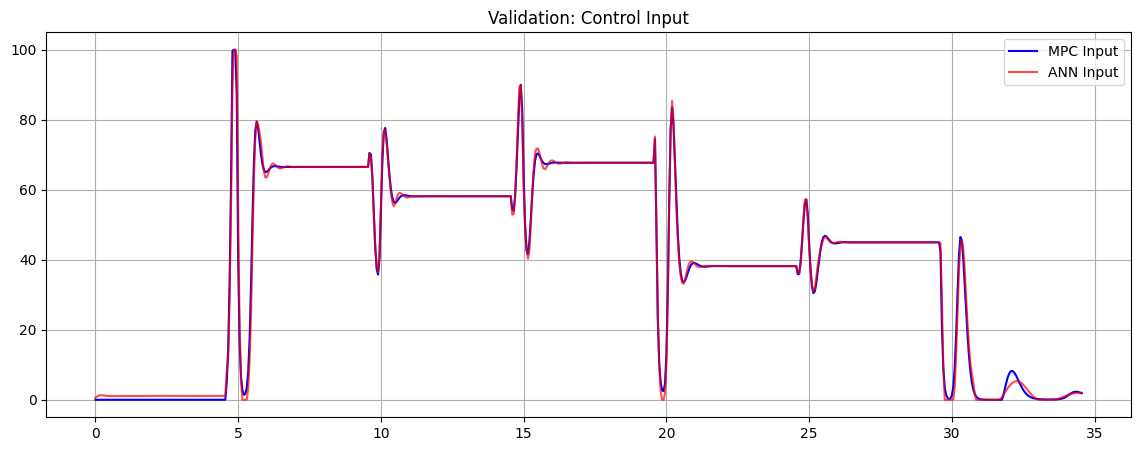

In [11]:
# 11. Validation Simulation (MPC vs ANN)
# Simulate MPC for Validation
xsim_val_mpc = np.zeros((nx, 1))
ysim_val_mpc = []
usim_val_mpc = []
w0_val = np.zeros(w.shape[0])

sim_steps_test = steps_test - N

start_time = time.time()
print("Simulating Optimal MPC on Test Signal...")
for k in range(sim_steps_test):
    ref_window = x2ref_val[k : k + N]
    pval = np.concatenate([xsim_val_mpc[:, -1], ref_window])
    
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    
    w_opt = sol['x'].full().flatten()
    u_opt = w_opt[nx]
    
    sim_step = F(x0=xsim_val_mpc[:, -1], p=u_opt)
    xk1 = sim_step['xf'].full().flatten()
    yk = sim_step['yk'].full().item()
    
    xsim_val_mpc = np.c_[xsim_val_mpc, xk1]
    usim_val_mpc.append(u_opt)
    ysim_val_mpc.append(yk)
    w0_val = w_opt
mpc_time = time.time() - start_time

# Simulate ANN
xsim_val_ann = np.zeros((nx, 1))
ysim_val_ann = []
usim_val_ann = []

start_time = time.time()
print("Simulating ANN on Test Signal...")
model.eval()
with torch.no_grad():
    for k in range(sim_steps_test):
        ref_window = x2ref_val[k : k + N]
        # pval = np.concatenate([xsim_val_ann[:, -1], ref_window])
        pval = np.concatenate([xsim_val_ann[:, -1], ref_window])
        
        # Normalize input exactly as in training
        pval_scaled = scaler.transform(pval.reshape(1, -1))
        p_tensor = torch.tensor(pval_scaled, dtype=torch.float32)
        
        # Predict (Directly outputs raw control value since we didn't scale Y)
        u_opt = model(p_tensor).item()
        
        # Bound the ANN output to strictly respect limits
        u_opt = np.clip(u_opt, data['u_min'][0], data['u_max'][0])
        
        sim_step = F(x0=xsim_val_ann[:, -1], p=u_opt)
        xk1 = sim_step['xf'].full().flatten()
        yk = sim_step['yk'].full().item()
        
        xsim_val_ann = np.c_[xsim_val_ann, xk1]
        usim_val_ann.append(u_opt)
        ysim_val_ann.append(yk)
ann_time = time.time() - start_time

print(f"MPC Simulation Time: {mpc_time:.2f} s")
print(f"ANN Simulation Time: {ann_time:.2f} s")
print(f"Speedup Factor: {mpc_time/ann_time:.2f}x")

tvec_plot = np.arange(0, sim_steps_test * Ts, Ts)

plt.figure(figsize=(14, 5))
plt.plot(tvec_plot, x2ref_val[:sim_steps_test], 'k--', label='Reference')
plt.plot(tvec_plot, ysim_val_mpc, 'b-', label='MPC')
plt.plot(tvec_plot, ysim_val_ann, 'r-', alpha=0.7, label='ANN')
plt.title('Validation: State Trajectory')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(tvec_plot, usim_val_mpc, 'b-', label='MPC Input')
plt.plot(tvec_plot, usim_val_ann, 'r-', alpha=0.7, label='ANN Input')
plt.title('Validation: Control Input')
plt.legend()
plt.grid()
plt.show()
